In [ ]:
pip install qiskit qiskit-aer 'qiskit[visualization]'

In [ ]:
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import quantum_volume
from qiskit.quantum_info import Operator
import numpy as np


#ADVANCED ARITHMETIC

Many gates in qiskit are stored as abstract mathmatical instructions, not direct hardware operations.

which is later on when given to transpiler, then transpiler decides:

*   how to implement and optimize them
*   how to rewrite them for backend



# Arithmetic and Comparison Function Gates in Qiskit

These gates implement mathematical functions and comparisons using reversible quantum circuits.

Used in:

- quantum finance
- optimization
- arithmetic circuits
- amplitude estimation
- quantum algorithms

---

# Gate Representation vs QuantumCircuit Representation

| Type | Meaning |
|---|---|
| Gate Representation | reusable gate object |
| QuantumCircuit Representation | full decomposed circuit |

---

# ExactReciprocalGate

## Exact Reciprocal Function Gate

Implements:

$$
f(x)=\frac1x
$$

on quantum-encoded values.

---

## Example

If:

$$
x=2
$$

then:

$$
f(x)=\frac12
$$

---

## Purpose

Used in:

- arithmetic circuits
- amplitude estimation
- quantum numerical algorithms

```python
ExactReciprocalGate(...)
```

---

# Important

The reciprocal must be implemented reversibly using quantum arithmetic operations.

---

# ExactReciprocal

## QuantumCircuit Representation

Full circuit implementation of reciprocal computation.

Contains decomposed arithmetic and control logic.

```python
ExactReciprocal(...)
```

---

# IntegerComparatorGate

## Integer Comparison Gate

Compares a quantum register against a classical integer.

Performs operations like:

$$
x \ge c
$$

or:

$$
x < c
$$

Where:

- \(x\) = quantum value
- \(c\) = classical constant

---

## Example

Compare:

$$
x \ge 5
$$

If true:

- target qubit flips

---

## Purpose

Used in:

- conditional logic
- threshold functions
- quantum finance
- Grover oracles

```python
IntegerComparatorGate(...)
```

---

# IntegerComparator

## QuantumCircuit Representation

Full comparison circuit implementation.

Uses:

- reversible subtraction
- carry logic
- comparator circuits

```python
IntegerComparator(...)
```

---

# QuadraticFormGate

## Quadratic Form Gate

Implements quadratic mathematical expressions.

General form:

$$
x^T A x
$$

Where:

| Symbol | Meaning |
|---|---|
| \(x\) | binary variable vector |
| \(A\) | coefficient matrix |

---

# Example

For binary variables:

$$
f(x_1,x_2)=x_1^2+2x_1x_2+x_2^2
$$

---

## Purpose

Used in:

- optimization problems
- QUBO formulations
- Ising models
- portfolio optimization

```python
QuadraticFormGate(...)
```

---

# QuadraticForm

## QuantumCircuit Representation

Full circuit implementing quadratic forms using reversible arithmetic.

```python
QuadraticForm(...)
```

---

# WeightedSumGate

## Weighted Sum Gate

Computes:

$$
\sum_i w_i x_i
$$

Where:

| Symbol | Meaning |
|---|---|
| \(w_i\) | weight |
| \(x_i\) | binary variable |

---

# Example

If:

$$
w=[2,3,5]
$$

and:

$$
x=[1,0,1]
$$

then:

$$
2(1)+3(0)+5(1)=7
$$

---

## Purpose

Used in:

- optimization
- arithmetic circuits
- weighted constraints
- quantum finance

```python
WeightedSumGate(weights)
```

---

# WeightedAdder

## QuantumCircuit Representation

Full weighted-sum arithmetic circuit.

Uses:

- reversible adders
- carry operations
- arithmetic synthesis

```python
WeightedAdder(weights)
```

---

# Important Concept

All these operations must be:

- reversible
- unitary

because quantum circuits cannot destroy information.

---

# Why These Gates Matter

Used heavily in:

| Area | Usage |
|---|---|
| Quantum Finance | payoff functions |
| Optimization | objective functions |
| Grover Oracles | condition checking |
| Arithmetic Circuits | mathematical computation |

---

# Difference Between Gate and Circuit Representation

| Gate Representation | Circuit Representation |
|---|---|
| reusable instruction object | full decomposed implementation |
| compact abstraction | explicit gate structure |
| appendable into circuits | detailed arithmetic circuit |

---

# Summary Table

| Component | Purpose |
|---|---|
| ExactReciprocalGate | computes \(1/x\) |
| IntegerComparatorGate | compares against integer |
| QuadraticFormGate | computes quadratic expression |
| WeightedSumGate | computes weighted sum |
| ExactReciprocal | reciprocal circuit |
| IntegerComparator | comparator circuit |
| QuadraticForm | quadratic-form circuit |
| WeightedAdder | weighted-sum circuit |

---

# Core Idea

These arithmetic-function gates implement reversible mathematical computations, comparisons, and weighted arithmetic on quantum registers.


**Gate Representation**

- **ExactReciprocalGate**:	Implements an exact reciprocal function `f(x) = 1/x`.
- **IntegerComparatorGate**:	Perform a `≥` or `<` on a qubit register against a classical integer.
- **QuadraticFormGate**:	Implements a quadratic form on binary variables encoded in qubit registers.
- **WeightedSumGate**:	A gate to compute the weighted sum `Σ(wᵢ -**xᵢ)` of qubit registers, each variable is multiplied by a specific weight.

**QuantumCircuit Representation**

- **ExactReciprocal**:	Exact reciprocal `QuantumCircuit` implmentation
- **IntegerComparator**:	Integer Comparator `QuantumCircuit` implmentation.
- **QuadraticForm**:	Quadratic form `QuantumCircuit` implmentation.
- **WeightedAdder**:	Weighted sum `QuantumCircuit` implmentation.

IntegerComparator(num_state_qubits=**None**, value=None, geq=True , name='cmp')

geq *(Return whether the comparator compares greater or less equal.)* or return/configure WHICH comparison mode is being used.

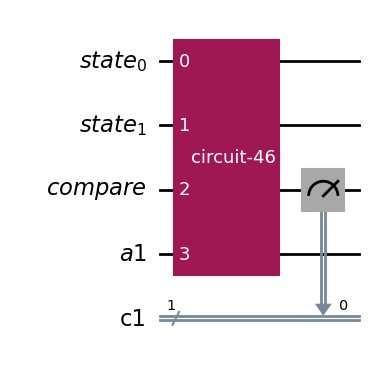

In [ ]:
from qiskit.circuit.library import IntegerComparator
# Compare if a 2-qubit number (0-3) is < 3
IC = IntegerComparator(2, 3, geq=False)
IC.add_register(ClassicalRegister(1))
#Result is stored in the third qubit (flips if condition is true)
#Output is 0 < 3  => True , third qubit should be flipped

IC.measure(2,0) #measures 2 and store the result in 0
IC.draw('mpl')

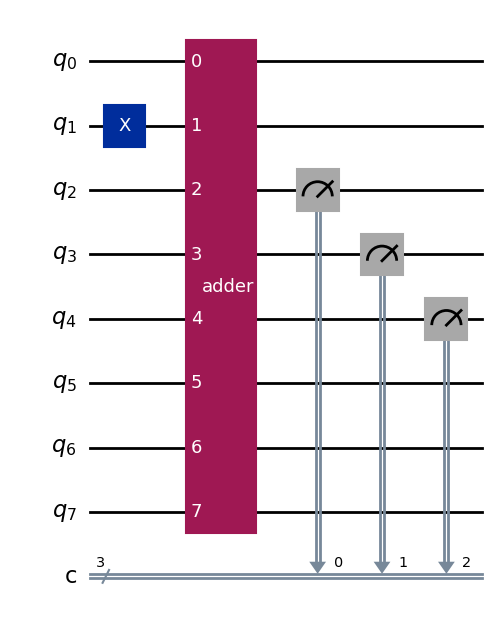

In [ ]:
from qiskit.circuit.library import WeightedAdder

ws = [2,3]

WA = WeightedAdder(2, weights=ws)
qc =  QuantumCircuit(WA.num_qubits, 3)

# setup input to represent x1=1 (qubit 1) and x0=0 (qubit 0)
qc.x(1)

qc.append(WA, range(WA.num_qubits))
# or qc.append(WA, WA.num_qubits) which is basically the same

#Output is stored in 3-qubit sum register in qubits 2,3,4

#Output is 3*1 + 2*0 = 3

qc.measure([2,3,4], [0,1,2])
# or qc.measure(range(2, 5), range(3)) which is basically the same

qc.draw('mpl')

the Weighted Adder usually contains

| Type           | Purpose               |
| -------------- | --------------------- |
| State qubits   | Input values          |
| Sum qubits     | Store weighted sum    |
| Carry qubits   | Arithmetic carry bits |
| Ancilla qubits | Temporary workspace   |


In [ ]:
WA = WeightedAdder(2, weights=ws)
qc =  QuantumCircuit(WA.num_qubits, 3)
print(WA.num_qubits)

8


printing 8 means the WeightedAdder circuit internally requires 8 total qubits to perform the weighted sum operation.

In [ ]:
print(WA.num_state_qubits)
print(WA.num_sum_qubits)
print(WA.num_carry_qubits)
print(WA.num_control_qubits)
print(WA.num_qubits)

2
3
2
1
8


In [ ]:
simu = AerSimulator()
result = simu.run(transpile(qc , simu), shots=1000).result()
# transpile(qc , simu) == Convert/optimize the quantum circuit qc so it can run correctly on the backend/simulator simu.
counts = result.get_counts(0)
# Get the measurement results (counts) of circuit number 0.
print("Measurements counts :" ,counts)

Measurements counts : {'011': 1000}


| Shot Number | Measured Output |
| ----------- | --------------- |
| 1           | 011             |
| 2           | 011             |
| 3           | 011             |
| ...         | ...             |
| 1000        | 011             |


# Measurement Counts in Qiskit

## Introduction

When a quantum circuit is executed in Qiskit, the measurement results are returned as a dictionary called **counts**.

The counts dictionary stores:

* The measured bitstrings
* How many times each bitstring occurred

---

## Example

```python
counts = {'011': 1000}
```

This means:

* The measured output was `011`
* It occurred `1000` times

So the circuit always produced:

[
011
]

---

# General Form of Counts

```python
{
    'bitstring' : frequency
}
```

Example:

```python
{
    '00': 512,
    '11': 488
}
```

This means:

| Measured State | Number of Times Measured |
| -------------- | ------------------------ |
| 00             | 512                      |
| 11             | 488                      |

---

# Meaning of Shots

Quantum circuits are usually executed multiple times.

Example:

```python
backend.run(qc, shots=1000)
```

This means:

[
\text{Execute the circuit 1000 times}
]

The counts dictionary records how many times each measurement result appears.

---

# Understanding {'011':1000}

```python
{'011':1000}
```

means:

[
011 \rightarrow 1000 \text{ times}
]

So after all executions, the output was always:

[
011
]

This usually indicates:

* A deterministic circuit
* Or a circuit with probability nearly equal to 1 for that state

---

# Bit Ordering in Qiskit

Qiskit displays classical bits in:

[
c_2; c_1; c_0
]

order from left to right.

This is called:

[
\textbf{Little-Endian Ordering}
]

---

# Important Concept

Many beginners expect Qiskit to display:

[
q_0; q_1; q_2
]

But Qiskit actually displays:

[
q_2; q_1; q_0
]

So the displayed order is reversed.

---

# Example of Bit Ordering

Suppose the qubits are measured as:

| Qubit | Value |
| ----- | ----- |
| q0    | 1     |
| q1    | 1     |
| q2    | 0     |

Then Qiskit displays:

[
011
]

because the displayed order is:

[
q_2 q_1 q_0
]

NOT:

[
q_0 q_1 q_2
]

---

# Example Circuit

```python
from qiskit import QuantumCircuit

qc = QuantumCircuit(3,3)

qc.x(0)
qc.x(1)

qc.measure([0,1,2],[0,1,2])
```

Explanation:

* `qc.x(0)` flips qubit 0 to state 1
* `qc.x(1)` flips qubit 1 to state 1
* qubit 2 remains 0

Final qubit states:

| Qubit | State |
| ----- | ----- |
| q0    | 1     |
| q1    | 1     |
| q2    | 0     |

Result:

```python
{'011':1000}
```

because Qiskit displays the bits in reverse order:

[
q_2 q_1 q_0 = 011
]

---

# Classical Bit Interpretation

Example:

```python
'101'
```

means:

| Classical Bit | Value |
| ------------- | ----- |
| c2            | 1     |
| c1            | 0     |
| c0            | 1     |

The leftmost bit corresponds to the highest-index classical bit.

---

# Accessing Counts in Qiskit

Example:

```python
counts = result.get_counts()
```

This retrieves the measurement frequencies.

If multiple circuits were executed:

```python
counts = result.get_counts(0)
```

means:

[
\text{Get counts of circuit index 0}
]

---

# Multiple Circuits Example

```python
job = backend.run([qc1, qc2], shots=1000)
```

Now:

| Index | Circuit |
| ----- | ------- |
| 0     | qc1     |
| 1     | qc2     |

Then:

```python
result.get_counts(0)
```

gets counts for the first circuit.

And:

```python
result.get_counts(1)
```

gets counts for the second circuit.

---

# Summary

| Concept           | Meaning                              |
| ----------------- | ------------------------------------ |
| counts            | Measurement frequency dictionary     |
| shots             | Number of circuit executions         |
| {'011':1000}      | Output 011 measured 1000 times       |
| Bit ordering      | Qiskit uses little-endian ordering   |
| Leftmost bit      | Highest classical bit index          |
| get_counts()      | Retrieves measurement frequencies    |
| get_counts(0)     | Gets counts of first circuit         |
| Multiple circuits | Can run multiple circuits in one job |


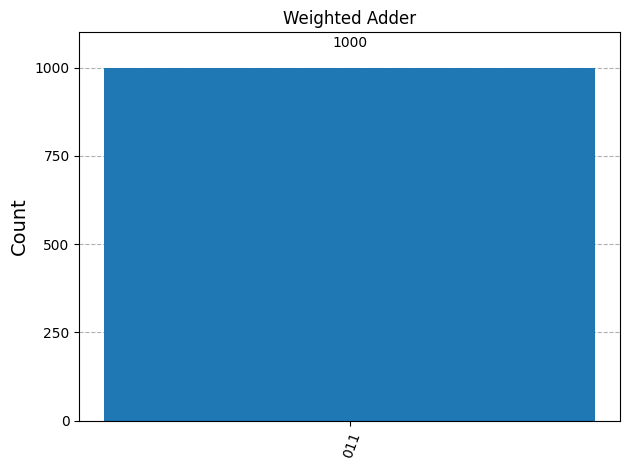

In [ ]:
plot_histogram(counts, title="Weighted Adder")